# Табличные данные: предсказание рейтинга фильма (FCN)

**Задача:** регрессия — предсказать `vote_average` по метаданным фильма.

**Бизнес-смысл:** платформа получает ожидаемый рейтинг фильма до релиза, что помогает
приоритизировать продвижение контента.

**Решения, принятые в EDA:**
- Постановка задачи: **регрессия** — сохраняет информацию о близости оценок
- Строки с нулевым/неизвестным бюджетом — **дропаются** (бюджет используется как признак, заполнение медианой искажало бы сигнал)
- Числовые признаки логарифмируются
- Жанр и язык — категориальные признаки, значимый предиктор по результатам EDA

**План:**
1. Загрузка и предобработка
2. Train/val/test split
3. Архитектура 1 — Shallow FCN (baseline)
4. Архитектура 2 — Deep FCN с BatchNorm + Dropout
5. Архитектура 3 — TabNet (нелекционная)
6. Логирование в MLflow, сравнение, выводы

## 0. Импорты

In [441]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow
import mlflow.pytorch

torch.manual_seed(67)
np.random.seed(67)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 1. Загрузка данных

In [ ]:
df = pd.read_csv('../data/processed/tmdb_clean.csv')
len(df)

27943

## 2. Предобработка

### 2.1 Фильтрация по бюджету

Решение: budget и revenue исключены из признаков.  
Серия экспериментов показала, что предсказательная сила этих признаков  
нулевая на датасетах от 8к до 28к строк (TabNet feature importance ~0  
во всех прогонах), при этом их включение требует либо дропа 72% данных,  
либо импутации которая не дала выигрыша.  Это уже дает нам первый бизнес инсайт,
 что деньги, вложенные в фильм, не говорят о том, как его оценят зрители, 
 поэтому работаем на полном датасете (vote_count >= 50 из EDA).  

In [443]:
df = df[
    df['runtime'].notna() & (df['runtime'] > 0) &
    df['popularity'].notna() &
    df['year'].notna()
].copy()

len(df)

27833

### 2.2 Логарифмирование числовых признаков

In [444]:
for col in ['popularity', 'vote_count']:
    df[f'log_{col}'] = np.log1p(df[col])

log_numeric_cols = ['log_popularity', 'log_vote_count', 'runtime', 'year']

df[log_numeric_cols].describe()

,log_popularity,log_vote_count,runtime,year
count,27833.000000,27833.000000,27833.000000,27833.000000
mean,2.449662,5.405157,99.778213,2001.136277
std,0.619807,1.281301,27.575678,21.411927
min,0.470004,3.931826,1.000000,1874.000000
25%,2.036795,4.394449,90.000000,1993.000000
50%,2.371085,5.036953,98.000000,2009.000000
75%,2.757792,6.100319,111.000000,2016.000000
max,8.004819,10.448599,585.000000,2023.000000


### 2.3 Категориальные признаки: жанры (multi-hot) и язык (top-N + other)

Берем жанровые колонки из EDA

In [445]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]
len(genre_cols), genre_cols

(19,
 ['genre_Action',
  'genre_Science Fiction',
  'genre_Adventure',
  'genre_Drama',
  'genre_Crime',
  'genre_Thriller',
  'genre_Fantasy',
  'genre_Comedy',
  'genre_Romance',
  'genre_Western',
  'genre_Mystery',
  'genre_War',
  'genre_Animation',
  'genre_Family',
  'genre_Horror',
  'genre_Music',
  'genre_History',
  'genre_TV Movie',
  'genre_Documentary'])

In [446]:
def parse_basic(val):
    if pd.isna(val) or val == "":
        return []

    val_str = str(val)

    clean_str = val_str.replace("[", "").replace("]", "").replace("'", "")
    return [c.strip() for c in clean_str.split(",") if c.strip()]

df["companies_list"] = df["production_companies"].apply(parse_basic)
df["primary_company"] = df["companies_list"].str[0]

df["countries_list"] = df["production_countries"].apply(parse_basic)
df["primary_country"] = df["countries_list"].str[0]


In [448]:
top_languages = df["original_language"].value_counts().head(15).index

df["language_grouped"] = df["original_language"].where(
    df["original_language"].isin(top_languages), "other"
)

lang_dummies = pd.get_dummies(
    df["language_grouped"], prefix="lang", dtype=int
)
df = pd.concat([df, lang_dummies], axis=1)
lang_cols = lang_dummies.columns.tolist()

top_languages, lang_dummies.columns


(Index(['en', 'fr', 'it', 'ja', 'es', 'de', 'ko', 'hi', 'zh', 'ru', 'cn', 'pt',
        'tr', 'pl', 'sv'],
       dtype='object', name='original_language'),
 Index(['lang_cn', 'lang_de', 'lang_en', 'lang_es', 'lang_fr', 'lang_hi',
        'lang_it', 'lang_ja', 'lang_ko', 'lang_other', 'lang_pl', 'lang_pt',
        'lang_ru', 'lang_sv', 'lang_tr', 'lang_zh'],
       dtype='object'))

In [450]:
top_companies = df["primary_company"].value_counts().head(15).index
df["company_grouped"] = df["primary_company"].fillna("unknown")
df["company_grouped"] = df["company_grouped"].where(
    df["company_grouped"].isin(top_companies)
    | (df["company_grouped"] == "unknown"),
    "other",
)

company_dummies = pd.get_dummies(
    df["company_grouped"], prefix="company", dtype=int
)
df = pd.concat([df, company_dummies], axis=1)

company_cols = company_dummies.columns.tolist()

top_countries = df["primary_country"].value_counts().head(10).index
df["country_grouped"] = df["primary_country"].fillna("unknown")
df["country_grouped"] = df["country_grouped"].where(
    df["country_grouped"].isin(top_countries)
    | (df["country_grouped"] == "unknown"),
    "other",
)

country_dummies = pd.get_dummies(
    df["country_grouped"], prefix="country", dtype=int
)
df = pd.concat([df, country_dummies], axis=1)

country_cols = country_dummies.columns.tolist()

top_companies, top_countries


(Index(['Universal Pictures', 'Paramount', 'Columbia Pictures',
        'Warner Bros. Pictures', '20th Century Fox', 'Metro-Goldwyn-Mayer',
        'Walt Disney Pictures', 'New Line Cinema', 'Walt Disney Productions',
        'Touchstone Pictures', 'United Artists', 'TriStar Pictures',
        'Warner Bros. Animation', 'Miramax', 'Gaumont'],
       dtype='object', name='primary_company'),
 Index(['United States of America', 'France', 'United Kingdom', 'Canada',
        'Italy', 'Japan', 'Germany', 'India', 'Belgium', 'Spain'],
       dtype='object', name='primary_country'))

### 2.4 Финальный набор признаков

In [452]:
feature_cols = (
    log_numeric_cols + genre_cols + lang_cols + company_cols + country_cols
)
target_col = "vote_average"

X = df[feature_cols].to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

len(feature_cols), X.shape, y.shape

(68, (27833, 68), (27833,))

## 3. Train/Val/Test split + нормализация

1. Разделение выборки (70/15/15).  
2. Масштабирование числовых признаков на месте (без лишних переменных).  
3. Перевод в тензоры PyTorch.   
Красивый и информативный вывод через встроенные средства PyTorch

In [454]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=67
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=67
)

n_numeric = len(log_numeric_cols)
scaler = StandardScaler()

X_train[:, :n_numeric] = scaler.fit_transform(X_train[:, :n_numeric])
X_val[:, :n_numeric] = scaler.transform(X_val[:, :n_numeric])
X_test[:, :n_numeric] = scaler.transform(X_test[:, :n_numeric])

X_train_t = torch.from_numpy(X_train)
X_val_t = torch.from_numpy(X_val)
X_test_t = torch.from_numpy(X_test)

INPUT_DIM = X_train_t.shape[1]


In [455]:
#Train tensor

X_train_t.shape, X_train_t.dtype

(torch.Size([19483, 68]), torch.float32)

In [456]:
#Val tensor

X_val_t.shape, X_val_t.dtype

(torch.Size([4175, 68]), torch.float32)

In [457]:
#Test tensor

X_test_t.shape, X_test_t.dtype

(torch.Size([4175, 68]), torch.float32)

In [459]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_ds = TabularDataset(X_train, y_train)
val_ds = TabularDataset(X_val, y_val)
test_ds = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

## 4. Обучающий цикл (общий для всех архитектур)

In [460]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, weight_decay=0.0):
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    criterion = nn.MSELoss()

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mae': []
    }

    epoch_bar = tqdm(range(epochs), desc="Training")

    for epoch in epoch_bar:
        model.train()
        train_losses = []

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs} [train]",
            leave=False
        )

        for xb, yb in train_bar:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()

            pred = model(xb)
            loss = criterion(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            train_losses.append(loss.item())
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        val_losses, val_maes = [], []

        with torch.no_grad():
            val_bar = tqdm(
                val_loader,
                desc=f"Epoch {epoch+1}/{epochs} [val]",
                leave=False
            )

            for xb, yb in val_bar:
                xb, yb = xb.to(device), yb.to(device)

                pred = model(xb)

                val_loss_batch = criterion(pred, yb).item()
                val_mae_batch = torch.abs(pred - yb).mean().item()

                val_losses.append(val_loss_batch)
                val_maes.append(val_mae_batch)

                val_bar.set_postfix(
                    loss=f"{val_loss_batch:.4f}",
                    mae=f"{val_mae_batch:.4f}"
                )

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        val_mae = np.mean(val_maes)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)

        epoch_bar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            val_loss=f"{val_loss:.4f}",
            val_mae=f"{val_mae:.4f}"
        )

    return model, history


def evaluate_model(model, test_loader):
    model.eval()

    preds, trues = [], []

    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc="Evaluating"):
            xb = xb.to(device)

            pred = model(xb).cpu().numpy()

            preds.append(pred)
            trues.append(yb.numpy())

    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()

    mae = mean_absolute_error(trues, preds)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return {'mae': mae, 'rmse': rmse, 'r2': r2}, preds, trues

## 5. MLflow setup

In [461]:
# mlflow server --host 127.0.0.1 --port 5000
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment('tmdb_rating_prediction_fcn')

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1781285194555, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1781285194555, lifecycle_stage='active', name='tmdb_rating_prediction_fcn', tags={}, trace_location=None, workspace='default'>

## 6. Baseline и линейная регрессия

Чтобы нам было с чем сравнивать наши результаты, получим значения для медианы(показывает, насколько вообще есть что предсказывать) и простой линейной регрессии(показывает, сколько сигнала вытягивается чисто линейно). Наша цель - переплюнуть эти показатели нашими действиями

In [462]:
# Предсказание среднего

median_pred = np.full_like(y_test, y_train.mean())
mae_baseline = mean_absolute_error(y_test, median_pred)
r2_baseline = r2_score(y_test, median_pred)
mae_baseline, r2_baseline

(0.6999040842056274, -0.0002828836441040039)

In [463]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
preds_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, preds_lr)
r2_lr = r2_score(y_test, preds_lr)
mae_lr, r2_lr

(0.5165413022041321, 0.4178692102432251)

## 7. Архитектура 1 — Shallow FCN (baseline)

In [464]:
class ShallowFCN(nn.Module):
    def __init__(self):
        super(ShallowFCN, self).__init__()

        self.fc1 = nn.Linear(INPUT_DIM, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [465]:
params_v1 = {'layers': [64], 'batchnorm': False, 'dropout': False, 'lr': 1e-3, 'epochs': 50, 'batch_size': BATCH_SIZE}

with mlflow.start_run(run_name='FCN_shallow_no_budget'):
    mlflow.log_params(params_v1)

    model_v1 = ShallowFCN()
    model_v1, history_v1 = train_model(model_v1, train_loader, val_loader, epochs=params_v1['epochs'], lr=params_v1['lr'])

    for epoch, (tl, vl, vm) in enumerate(zip(history_v1['train_loss'], history_v1['val_loss'], history_v1['val_mae'])):
        mlflow.log_metrics({'train_loss': tl, 'val_loss': vl, 'val_mae': vm}, step=epoch)

    metrics_v1, preds_v1, trues_v1 = evaluate_model(model_v1, test_loader)
    mlflow.log_metrics({'test_mae': metrics_v1['mae'], 'test_rmse': metrics_v1['rmse'], 'test_r2': metrics_v1['r2']})

    mlflow.pytorch.log_model(model_v1, 'model')

    print(f"\nTest MAE: {metrics_v1['mae']:.4f} | RMSE: {metrics_v1['rmse']:.4f} | R2: {metrics_v1['r2']:.4f}")

Evaluating: 100%|██████████| 66/66 [00:00<00:00, 877.50it/s]
2026/06/16 06:43:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 06:43:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Test MAE: 0.4536 | RMSE: 0.5961 | R2: 0.5408
🏃 View run FCN_shallow_no_budget at: http://127.0.0.1:5000/#/experiments/2/runs/a877506b70804e18967ad5b0b73b162c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


Сначала взяли широкую [256, 128, 64] со стандартным lr=1e-3 и dropout 0.3 — и она училась нестабильно (val_loss скакал от эпохи к эпохе, а итог вышел хуже простой Shallow FCN). Похоже, сеть была слишком глубокой для наших 28 тысяч строк и при большом шаге обучения просто перепрыгивала минимум. Чтобы улучшить результат сузили слои до [128, 64, 32], снизили lr до 2e-4 и добавили обрезку градиента (clip_grad_norm). Dropout заодно убавили с 0.3 до 0.15, тк у более узкой сети агрессивная регуляризация уже лишняя. Колебания стали меньше, но до конца не ушли, при таком объеме данных и BatchNorm с батчем 64 это ожидаемо.

mae, rmse, r2

Простая сеть с одним скрытым слоем дала MAE=0.454 и R^2=0.541, что лучше линейной регрессии, значит в данных действительно есть нелинейность, которую сеть ловит, а линейная модель упускает.

## 8. Архитектура 2 — FC_Net

In [466]:
class DeepFCN(nn.Module):
    def __init__(self, batchnorm=True, dropout=True):
        super(DeepFCN, self).__init__()

        self.fc1 = nn.Linear(INPUT_DIM, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)

        if batchnorm:
            self.bn = nn.BatchNorm1d(128)
        else:
            self.bn = lambda x: x

        if dropout:
            self.dropout = nn.Dropout(0.15)
        else:
            self.dropout = lambda x: x

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.bn(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.dropout(x)
        x = self.fc4(x)
        return x

In [467]:
params_v2 = {
    'layers': [128, 64, 32],
    'batchnorm': True,
    'dropout': True,
    'dropout_p': 0.15,
    'lr': 2e-4,
    'weight_decay': 1e-4,
    'epochs': 50,
    'batch_size': BATCH_SIZE,
    'patience': 10
}

with mlflow.start_run(run_name='FCN_deep_tuned'):
    mlflow.log_params(params_v2)

    model_v2 = DeepFCN(batchnorm=params_v2['batchnorm'], dropout=params_v2['dropout'])
    model_v2, history_v2 = train_model(model_v2, train_loader, val_loader, epochs=params_v2['epochs'], lr=params_v2['lr'], weight_decay=params_v2['weight_decay'])

    for epoch, (tl, vl, vm) in enumerate(zip(history_v2['train_loss'], history_v2['val_loss'], history_v2['val_mae'])):
        mlflow.log_metrics({'train_loss': tl, 'val_loss': vl, 'val_mae': vm}, step=epoch)

    metrics_v2, preds_v2, trues_v2 = evaluate_model(model_v2, test_loader)
    mlflow.log_metrics({'test_mae': metrics_v2['mae'], 'test_rmse': metrics_v2['rmse'], 'test_r2': metrics_v2['r2']})

    mlflow.pytorch.log_model(model_v2, 'model')

    print(f"\nTest MAE: {metrics_v2['mae']:.4f} | RMSE: {metrics_v2['rmse']:.4f} | R2: {metrics_v2['r2']:.4f}")

Evaluating: 100%|██████████| 66/66 [00:00<00:00, 673.79it/s]
2026/06/16 06:44:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 06:44:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Test MAE: 0.4581 | RMSE: 0.5988 | R2: 0.5366
🏃 View run FCN_deep_tuned at: http://127.0.0.1:5000/#/experiments/2/runs/3b6bb19684d14fe0bb165f6f4d348f33
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


mae, rmse, r2

Глубокая сеть с BatchNorm и Dropout дала MAE=0.458, т.е. чуть хуже простой Shallow FCN, а не лучше, что наводит на мысль что дополнительного сигнала в данных для нее просто нет.

## 9. Архитектура 3 — TabNet

TabNet использует attention-механизм для выбора признаков на каждом шаге — даёт
встроенную интерпретируемость (feature importance), что особенно ценно учитывая
слабые линейные корреляции, найденные в EDA.

Установка: `pip install pytorch-tabnet`

In [468]:
from pytorch_tabnet.tab_model import TabNetRegressor

params_v3 = {
    'n_d': 16, 'n_a': 16, 'n_steps': 6, 'gamma': 1.0,
    'lr': 2e-2, 'epochs': 100, 'patience': 15, 'batch_size': BATCH_SIZE
}

with mlflow.start_run(run_name='TabNet_regressor'):
    mlflow.log_params(params_v3)

    tabnet = TabNetRegressor(
        n_d=params_v3['n_d'], n_a=params_v3['n_a'],
        n_steps=params_v3['n_steps'], gamma=params_v3['gamma'],
        optimizer_params=dict(lr=params_v3['lr']),
        seed=67
    )

    tabnet.fit(
        X_train=X_train, y_train=y_train.reshape(-1, 1),
        eval_set=[(X_val, y_val.reshape(-1, 1))],
        eval_metric=['mae'],
        max_epochs=params_v3['epochs'],
        patience=params_v3['patience'],
        batch_size=params_v3['batch_size']
    )

    for epoch, (tl, vl) in enumerate(zip(tabnet.history['loss'], tabnet.history['val_0_mae'])):
        mlflow.log_metrics({'train_loss': tl, 'val_mae': vl}, step=epoch)

    preds_v3 = tabnet.predict(X_test).flatten()
    mae_v3 = mean_absolute_error(y_test, preds_v3)
    rmse_v3 = np.sqrt(mean_squared_error(y_test, preds_v3))
    r2_v3 = r2_score(y_test, preds_v3)

    mlflow.log_metrics({'test_mae': mae_v3, 'test_rmse': rmse_v3, 'test_r2': r2_v3})

    tabnet.save_model('tabnet_model')
    mlflow.log_artifact('tabnet_model.zip')

    metrics_v3 = {'mae': mae_v3, 'rmse': rmse_v3, 'r2': r2_v3}
    print(f"\nTest MAE: {mae_v3:.4f} | RMSE: {rmse_v3:.4f} | R2: {r2_v3:.4f}")

/Users/vladislav/Desktop/GP5/GP5-TEAM3/.venv/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.00796 | val_0_mae: 0.68461 |  0:00:03s
epoch 1  | loss: 0.6517  | val_0_mae: 0.6549  |  0:00:07s
epoch 2  | loss: 0.58746 | val_0_mae: 0.58419 |  0:00:13s
epoch 3  | loss: 0.5221  | val_0_mae: 0.52643 |  0:00:19s
epoch 4  | loss: 0.51715 | val_0_mae: 0.52305 |  0:00:23s
epoch 5  | loss: 0.5083  | val_0_mae: 0.49869 |  0:00:27s
epoch 6  | loss: 0.47863 | val_0_mae: 0.52611 |  0:00:30s
epoch 7  | loss: 0.47339 | val_0_mae: 0.69152 |  0:00:34s
epoch 8  | loss: 0.4733  | val_0_mae: 0.48803 |  0:00:38s
epoch 9  | loss: 0.48365 | val_0_mae: 0.51372 |  0:00:42s
epoch 10 | loss: 0.46074 | val_0_mae: 0.49941 |  0:00:45s
epoch 11 | loss: 0.43961 | val_0_mae: 0.48307 |  0:00:49s
epoch 12 | loss: 0.42625 | val_0_mae: 0.52234 |  0:00:53s
epoch 13 | loss: 0.44403 | val_0_mae: 0.52009 |  0:00:56s
epoch 14 | loss: 0.45298 | val_0_mae: 0.52816 |  0:01:00s
epoch 15 | loss: 0.45055 | val_0_mae: 0.50793 |  0:01:04s
epoch 16 | loss: 0.42671 | val_0_mae: 0.49102 |  0:01:07s
epoch 17 | los

/Users/vladislav/Desktop/GP5/GP5-TEAM3/.venv/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at tabnet_model.zip

Test MAE: 0.4525 | RMSE: 0.5931 | R2: 0.5453
🏃 View run TabNet_regressor at: http://127.0.0.1:5000/#/experiments/2/runs/2cd76d3f18504d4a99586870217e4d53
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


На старте (n_steps=3, gamma=1.3) модель почти всю важность отдавала одному-двум признакам, а у двух десятков остальных важность была нулевая, то есть attention схлопывался. Увеличили число шагов до 6 и снизили gamma до 1.0 (это меньший штраф за повторное использование признака на разных шагах) и важность распределилась заметно ровнее. Проверили на двух random seed и получили картина важности признаков повторяется, так что это не случайность конкретного прогона.

mae, rmse, r2

Все три архитектуры, от однослойной сети до TabNet, уперлись практически в одно и то же значение

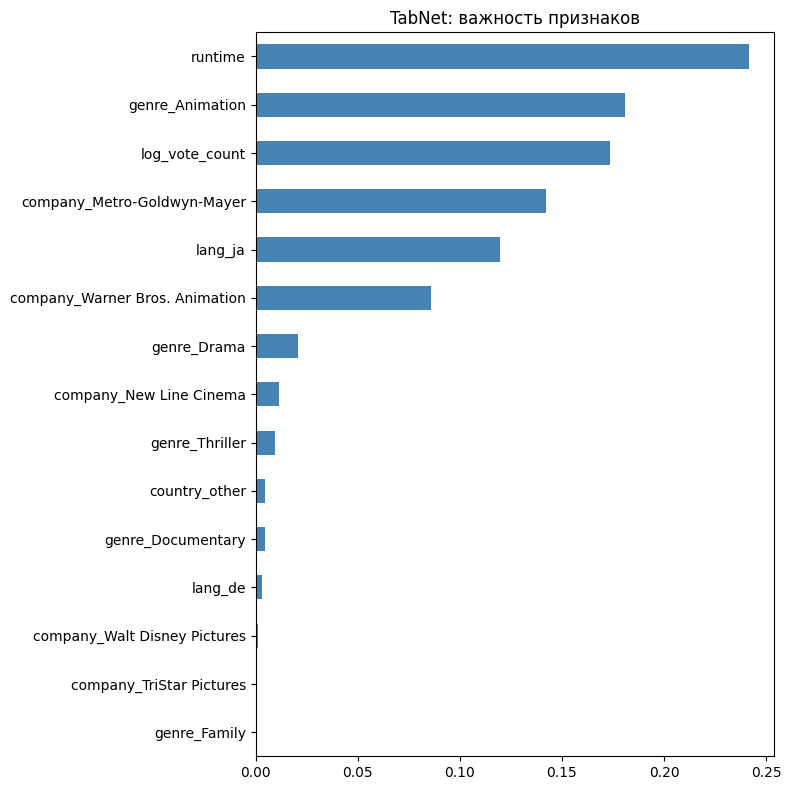

,0
runtime,0.241706
genre_Animation,0.180820
log_vote_count,0.173560
company_Metro-Goldwyn-Mayer,0.142377
lang_ja,0.119467
...,...
lang_other,0.000000
lang_pl,0.000000
lang_ru,0.000000
lang_sv,0.000000


In [469]:
# Feature importance из TabNet - дополнительный бизнес-инсайт
importances = pd.Series(tabnet.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('TabNet: важность признаков')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/tabnet_feature_importance.png', bbox_inches='tight')
plt.show()

importances.to_frame()

Длина фильма влияет на восприятие сильнее, чем можно было ожидать(клиповое мышление?), дальше анимация как жанр (она и в EDA была среди самых высокооцениваемых), известность фильма, отдельные студии (Metro-Goldwyn-Mayer) и язык (японский, вероятно, аниме и авторское кино с лояльной аудиторией). То есть на зрительскую оценку влияют скорее «качественные» характеристики фильма, чем деньги

In [470]:
print(len(tabnet.feature_importances_))
print(len(feature_cols))
print(X_train.shape)

68
68
(19483, 68)


## 10. Сравнение архитектур и выводы

In [481]:
comparison = pd.DataFrame({
    'Architecture': ['Shallow FCN', 'Deep FCN (BN+Dropout)', 'TabNet'],
    'MAE': [metrics_v1['mae'], metrics_v2['mae'], metrics_v3['mae']],
    'RMSE': [metrics_v1['rmse'], metrics_v2['rmse'], metrics_v3['rmse']],
    'R2': [metrics_v1['r2'], metrics_v2['r2'], metrics_v3['r2']]
})

comparison


,Architecture,MAE,RMSE,R2
0,Shallow FCN,0.453645,0.596100,0.540808
1,Deep FCN (BN+Dropout),0.458064,0.598847,0.536565
2,TabNet,0.452485,0.593146,0.545347


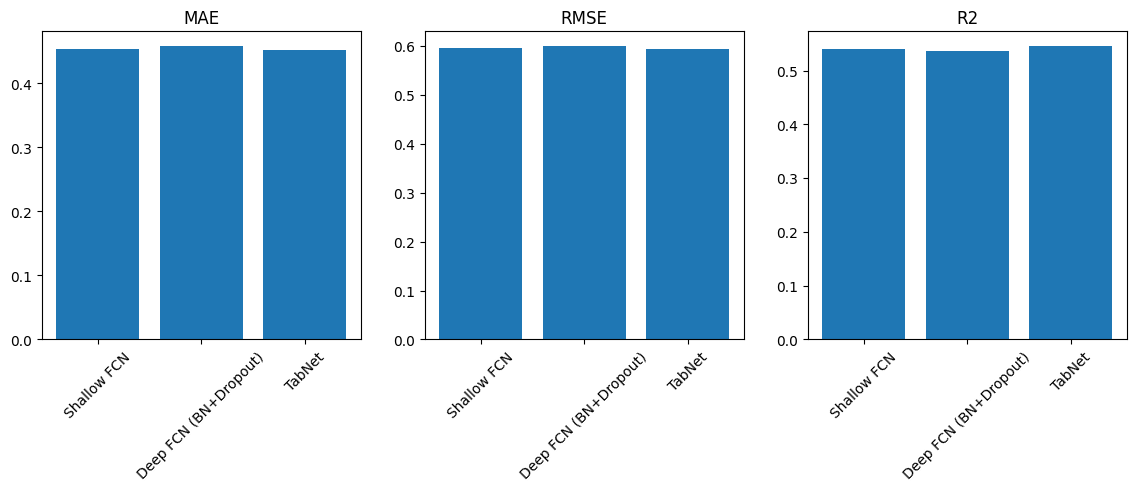

In [486]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(comparison['Architecture'], comparison[metric])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=45)    

plt.savefig('../data/processed/fcn_comparison.png')
plt.show()

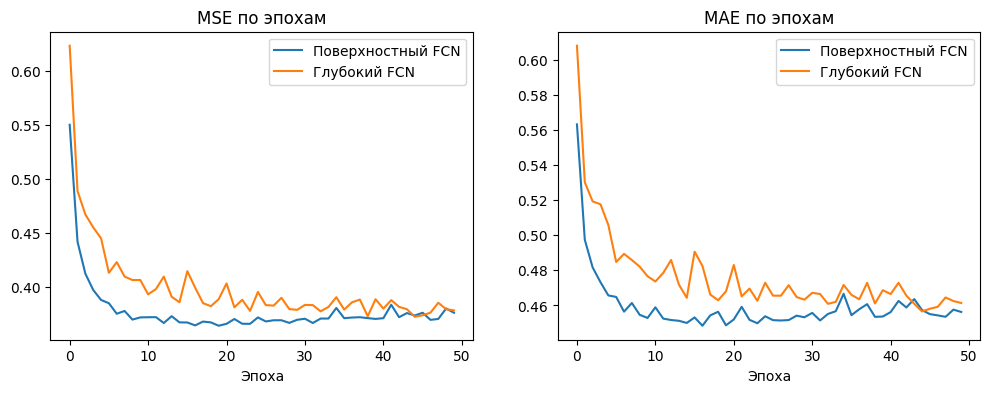

In [487]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_v1['val_loss'], label='Поверхностный FCN')
axes[0].plot(history_v2['val_loss'], label='Глубокий FCN')
axes[0].set_title('MSE по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].legend()

axes[1].plot(history_v1['val_mae'], label='Поверхностный FCN')
axes[1].plot(history_v2['val_mae'], label='Глубокий FCN')
axes[1].set_title('MAE по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].legend()

plt.savefig('../data/processed/fcn_training_curves.png')
plt.show()

### Выводы

Были испрльзованы три архитектуры и они дали практически одинаковый результат(MAE в районе 0.45, R^2 около 0.54. Shallow FCN 0.454, Deep FCN 0.458 (чуть хуже), TabNet 0.4525 (чуть лучше), но разброс между ними меньше сотой). Соответственнр в нашей задаче выбор архитектуры почти ничего не решает. Самая сильная корреляция отдельного признака с рейтингом была всего 0.24, у большинства меньше 0.1. Это значит, что проблема не в подобраных моделях, а в изначальных данных. Рейтинг фильма зависит от вещей, которых в метаданных просто нет — качество сценария, актеры, бюджеты, вкусы зрителей, то есть добавляьб глубину тут нечему, соответственно улучшать надо не архитектуру, а признаки. Самый перспективный источник данных — текстовые описания фильмов (через эмбеддинги) и данные о составе актёров. Это даст больше, чем любое усложнение сети.

Имеем вывод для бизнеса, что точно угадать балл модель не может, ошибка составляет ~0.45 на шкале, где почти все фильмы лежат в диапазоне 5.5–7.5, слишком велика для точечных решений, но для выбранной задачи (решить, что продвигать в первую очередь) — точный балл и не нужен, достаточно отличать потенциально удачные фильмы от слабых. Прямую метрику ранжирования в этой версии мы не считали, это следующий логичный шаг, но по характеру задачи модель пригоднее именно для приоритизации, а не для выставления оценки.